# EBSD polycrystalline material


In [1]:
import multiprocessing as mp
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyhectr.ebsd_map import (
    coerce_angle_cols,
    apply_affine,
    fit_affine,
    invert_affine,
    calibrate_ebsd_to_mm,
    plot_axis_orientation_map_clickable,
    read_ebsd_region,
)
from pyhectr.polycrystal import add_axes_indices_poly_parallel
from pyhectr.polyxsim import write_polyxsim_inp_from_ebsd

# Needed on Linux/HPC when multiprocessing is used from a notebook.
mp.set_start_method("fork", force=True)


## 1. Load EBSD table

In [2]:
FILE_PATH = Path("Nb_706_sample_primary_CS0.txt")  # change to your EBSD export

df = pd.read_csv(FILE_PATH, sep=r"\s+", engine="python")

rename_map = {
    "Index": "ID",
    "Euler1": "phi1",
    "Euler2": "PHI",
    "Euler3": "phi2",
    "Grain": "Grain_ID",
    "Grain ID": "Grain_ID",
}
df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)
df = coerce_angle_cols(df, ("phi1", "PHI", "phi2"))

df.head()


,ID,Phase,X,Y,phi1,PHI,phi2,MAD,BC,BS,...,ReliabilityIndex,G11,G12,G13,G21,G22,G23,G31,G32,G33
0,1,1,0,0,0.5906,15.253,61.119,0.3422,133,23,...,0.0,0.47425,-0.88038,0.00271,0.84972,0.45692,-0.26307,0.23036,0.12707,0.96477
1,2,1,2,0,0.9326,15.279,60.784,0.3176,138,25,...,0.0,0.47434,-0.88033,0.00429,0.84977,0.45658,-0.26349,0.23000,0.12863,0.96465
2,3,1,4,0,0.8114,15.192,60.871,0.3408,137,26,...,0.0,0.47478,-0.88009,0.00371,0.84981,0.45734,-0.26203,0.22891,0.12756,0.96505
3,4,1,6,0,1.0844,15.249,60.648,0.3808,106,16,...,0.0,0.47417,-0.88042,0.00498,0.85006,0.45634,-0.26296,0.22925,0.12892,0.96479
4,5,1,8,0,33.5640,27.342,34.333,0.3065,140,24,...,0.0,0.41110,-0.87551,0.25394,0.87401,0.29939,-0.38272,0.25905,0.37928,0.88828


## 2. Index EBSD orientations with nearest low-index crystal directions

In [3]:
MAX_Z = 12
N_WORKERS = 24

df_lab_gT = add_axes_indices_poly_parallel(
    df,
    maxZ=MAX_Z,
    euler_to_axes_mode="transpose",
    n_workers=N_WORKERS,
)

df_lab_gT.head()


Starting parallel indexing with 24 workers. Max Index: 12
Candidate space size approx: 7812.5 directions


Indexing grains: 100%|██████████| 19/19 [00:04<00:00,  4.03it/s]


,ID,Phase,X,Y,phi1,PHI,phi2,MAD,BC,BS,...,G31,G32,G33,uvw_X,uvw_Y,uvw_Z,ang_uvw_X_deg,ang_uvw_Y_deg,ang_uvw_Z_deg,handedness
0,1,1,0,0,0.5906,15.253,61.119,0.3422,133,23,...,0.23036,0.12707,0.96477,"[+6,-11,+0]","[+9,+5,-3]","[+2,+1,+8]",0.337462,1.248508,0.715185,1116.0
1,2,1,2,0,0.9326,15.279,60.784,0.3176,138,25,...,0.23000,0.12863,0.96465,"[+6,-11,+0]","[+9,+5,-3]","[+2,+1,+8]",0.383595,1.240331,0.782097,1116.0
2,3,1,4,0,0.8114,15.192,60.871,0.3408,137,26,...,0.22891,0.12756,0.96505,"[+6,-11,+0]","[+9,+5,-3]","[+2,+1,+8]",0.339773,1.287400,0.802107,1116.0
3,4,1,6,0,1.0844,15.249,60.648,0.3808,106,16,...,0.22925,0.12892,0.96479,"[+6,-11,+0]","[+9,+5,-3]","[+2,+1,+8]",0.417310,1.277175,0.827325,1116.0
4,5,1,8,0,33.5640,27.342,34.333,0.3065,140,24,...,0.25905,0.37928,0.88828,"[+5,-11,+3]","[+9,+3,-4]","[+2,+3,+7]",1.029646,0.566828,0.308377,1009.0


## 3. Plot clickable orientation maps

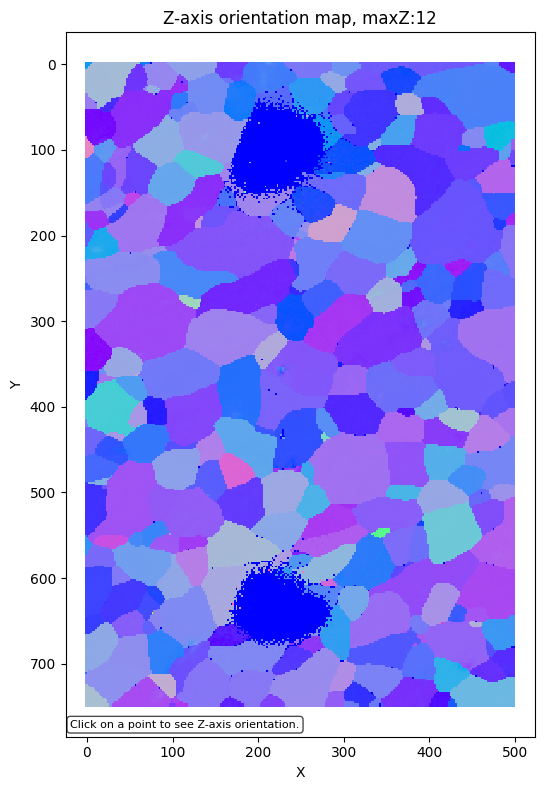

In [4]:
%matplotlib inline

# to make map interactive
# %matplotlib widget  


fig, ax = plot_axis_orientation_map_clickable(
    df_lab_gT,
    axis="Z",
    gamma=0.51,
    mode="gamma",
    title=f"Z-axis orientation map, maxZ:{MAX_Z}",
)

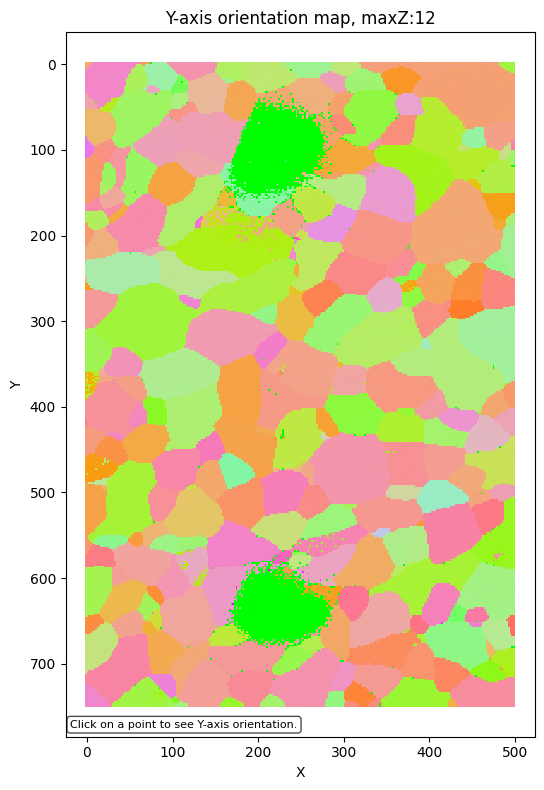

In [5]:
fig, ax = plot_axis_orientation_map_clickable(
    df_lab_gT,
    axis="Y",
    gamma=0.51,
    mode="gamma",
    title=f"Y-axis orientation map, maxZ:{MAX_Z}",
)


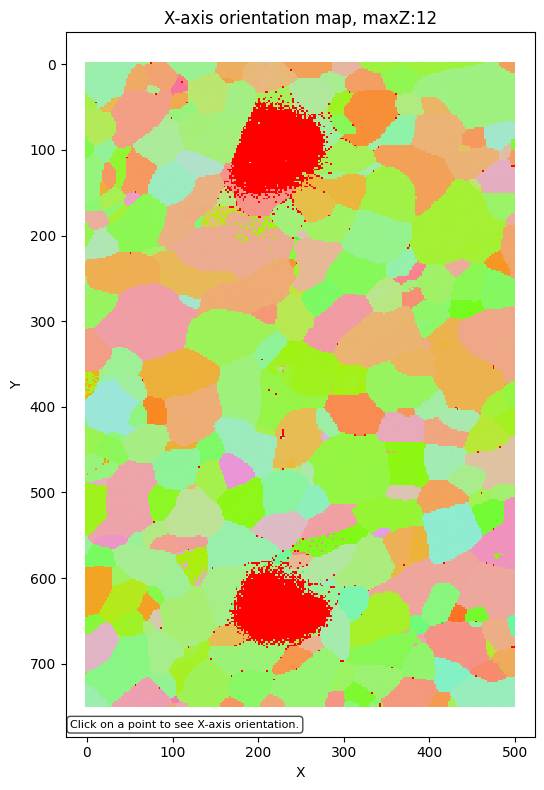

In [6]:
fig, ax = plot_axis_orientation_map_clickable(
    df_lab_gT,
    axis="X",
    gamma=0.51,
    mode="gamma",
    title=f"X-axis orientation map, maxZ:{MAX_Z}",
)


## 4. Calibrate EBSD pixels to sample mm coordinates

In [7]:
# Known map corners in sample/mm coordinates.
points_mm = np.array([
    [1.269, 1.588],
    [1.369, 1.031],
    [1.922, 1.120],
    [1.829, 1.669],
])

# EBSD pixel coordinates (X, Y)
ebsd_pts = np.array([
    [150, 660],
    [308, 654],
    [334, 550],
], float)

# Corresponding mm coordinates
mm_pts = np.array([
    [1.2817, 1.0045],
    [1.45,   1.0334],
    [1.46275,1.14602],
], float)

cal = calibrate_ebsd_to_mm(df, points_mm, x_col="X", y_col="Y")
cal

{'A_ebsd_to_mm': array([[ 0.00111747, -0.00012901],
        [ 0.00017068,  0.0007393 ]]),
 't_ebsd_to_mm': array([1.36725, 1.033  ]),
 'A_mm_to_ebsd': array([[ 871.64619382,  152.10462514],
        [-201.2362833 , 1317.5057842 ]]),
 't_mm_to_ebsd': array([-1348.88233628, -1085.84316673]),
 'ebsd_corners': array([[  0.,   0.],
        [498.,   0.],
        [498., 748.],
        [  0., 748.]]),
 'mm_corners': array([[1.369, 1.031],
        [1.922, 1.12 ],
        [1.829, 1.669],
        [1.269, 1.588]]),
 'rmse_mm': 0.0026575364531837248}

## 5. Convert a known grain position from mm to EBSD coordinates

In [8]:
manual_cal = {}

manual_cal["A_ebsd_to_mm"], manual_cal["t_ebsd_to_mm"] = fit_affine(
    ebsd_pts,
    mm_pts,
)

manual_cal["A_mm_to_ebsd"], manual_cal["t_mm_to_ebsd"] = invert_affine(
    manual_cal["A_ebsd_to_mm"],
    manual_cal["t_ebsd_to_mm"],
)

grain8_mm = np.array([1.3, 1.0])
grain8_ebsd = apply_affine(
    grain8_mm,
    manual_cal["A_mm_to_ebsd"],
    manual_cal["t_mm_to_ebsd"],
)

print("grain 8 in EBSD coords (X,Y):", grain8_ebsd)

grain 8 in EBSD coords (X,Y): [166.20905911 666.51352629]


## 6. Select a beam footprint / ROI

In [9]:
x0, y0 = grain8_ebsd

dx_mm = np.array([1, 0]) @ cal["A_ebsd_to_mm"].T  # mm per px in X
dy_mm = np.array([0, 1]) @ cal["A_ebsd_to_mm"].T  # mm per px in Y
step_x = np.linalg.norm(dx_mm)
step_y = np.linalg.norm(dy_mm)

r_mm = 0.013327
rx_px = r_mm / step_x
ry_px = r_mm / step_y

df_roi = read_ebsd_region(
    df,
    x0=float(x0),
    y0=float(y0),
    shape="ellipse",
    rx=rx_px,
    ry=ry_px,
    angle_deg=0,
)

df_roi


,ID,Phase,X,Y,phi1,PHI,phi2,MAD,BC,BS,...,ReliabilityIndex,G11,G12,G13,G21,G22,G23,G31,G32,G33
81331,81332,1,162,650,219.990,24.461,23.533,0.3212,68,11,...,0.0,-0.46892,0.84221,-0.26609,-0.86763,-0.38284,0.31725,0.16532,0.37963,0.91025
81332,81333,1,164,650,219.540,25.179,23.804,0.6830,64,10,...,0.0,-0.47299,0.83840,-0.27087,-0.86417,-0.38153,0.32808,0.17172,0.38926,0.90498
81333,81334,0,166,650,0.000,0.000,0.000,0.0000,70,10,...,0.0,1.00000,-0.00000,0.00000,0.00000,1.00000,-0.00000,0.00000,0.00000,1.00000
81334,81335,1,168,650,219.890,24.254,24.127,1.1431,58,11,...,0.0,-0.46124,0.84727,-0.26344,-0.87124,-0.37629,0.31519,0.16792,0.37490,0.91173
81335,81336,1,170,650,218.160,24.799,24.798,0.7360,53,9,...,0.0,-0.47852,0.83896,-0.25916,-0.86028,-0.38880,0.32979,0.17592,0.38076,0.90779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85333,85334,1,166,682,37.121,14.728,29.479,0.7839,100,14,...,0.0,0.40690,-0.90049,0.15342,0.90486,0.37434,-0.20271,0.12510,0.22131,0.96715
85334,85335,1,168,682,37.286,14.907,28.907,0.7819,106,15,...,0.0,0.41351,-0.89706,0.15585,0.90197,0.38021,-0.20468,0.12435,0.22520,0.96634
85335,85336,1,170,682,37.854,14.651,28.605,0.6702,106,14,...,0.0,0.40896,-0.89926,0.15521,0.90448,0.37686,-0.19971,0.12110,0.22206,0.96748
85583,85584,1,166,684,37.206,14.795,29.160,0.7703,105,16,...,0.0,0.41066,-0.89862,0.15441,0.90326,0.37783,-0.20338,0.12442,0.22299,0.96685


## 7. Process the ROI at one or several search limits

In [10]:
df_roi_processed_6 = add_axes_indices_poly_parallel(
    df_roi,
    maxZ=6,
    euler_to_axes_mode="transpose",
    n_workers=N_WORKERS,
)

df_roi_processed_6.head()


Starting parallel indexing with 24 workers. Max Index: 6
Candidate space size approx: 1098.5 directions


Indexing grains: 100%|██████████| 1/1 [00:00<00:00,  2.69it/s]


,ID,Phase,X,Y,phi1,PHI,phi2,MAD,BC,BS,...,G31,G32,G33,uvw_X,uvw_Y,uvw_Z,ang_uvw_X_deg,ang_uvw_Y_deg,ang_uvw_Z_deg,handedness
81331,81332,1,162,650,219.99,24.461,23.533,0.3212,68,11,...,0.16532,0.37963,0.91025,"[-3,+6,-2]","[-5,-2,+2]","[+1,+2,+5]",2.706459,2.664695,1.299353,220.0
81332,81333,1,164,650,219.54,25.179,23.804,0.6830,64,10,...,0.17172,0.38926,0.90498,"[-3,+6,-2]","[-5,-2,+2]","[+1,+2,+5]",2.894418,2.262610,1.581029,220.0
81333,81334,0,166,650,0.00,0.000,0.000,0.0000,70,10,...,0.00000,0.00000,1.00000,"[+1,+0,+0]","[+0,+1,+0]","[+0,+0,+1]",0.000000,0.000000,0.000000,1.0
81334,81335,1,168,650,219.89,24.254,24.127,1.1431,58,11,...,0.16792,0.37490,0.91173,"[-3,+6,-2]","[-5,-2,+2]","[+1,+2,+5]",2.335400,2.484277,1.011044,220.0
81335,81336,1,170,650,218.16,24.799,24.798,0.7360,53,9,...,0.17592,0.38076,0.90779,"[-3,+6,-2]","[-5,-2,+2]","[+1,+2,+5]",3.406226,2.621594,1.015293,220.0


In [11]:
# Optional: compare several ROI radii or search limits.
# df_roi_processed_12 = add_axes_indices_poly_parallel(df_roi, maxZ=12, euler_to_axes_mode="transpose", n_workers=N_WORKERS)
# df_roi_processed_96 = add_axes_indices_poly_parallel(df_roi, maxZ=96, euler_to_axes_mode="transpose", n_workers=N_WORKERS)


## 8. Write a PolyXSim input file from the EBSD ROI

In [12]:
direc = "./"
stem = "grain_1_ebsd"

write_polyxsim_inp_from_ebsd(
    "polyNb_from_ebsd_r_13_327.inp",
    wavelength_A=0.664008112030619,
    distance_mm=221.339,
    dety_center_px=1482.502,
    detz_center_px=2450.436,
    y_size_mm=0.075,
    z_size_mm=0.075,
    dety_size_px=3110,
    detz_size_px=2500,
    omega_start=60.0,
    omega_end=340.0,
    omega_step=0.25,
    theta_min=0.0,
    theta_max=25.0,
    o11=1,
    o12=0,
    o21=0,
    o22=-1,
    region_df=df_roi,
    use_Gcols=True,
    U_equals="gt", 
    pos_mode="zero",
    direc=direc,
    stem=stem,
)


Wrote PolyXSim input to 'polyNb_from_ebsd_r_13_327.inp'
